In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [2]:
# Load dataset
df = pd.read_csv(r"C:\Users\hp\OneDrive\Desktop\cafe-revenue-prediction-analytics\Dataset\retail_sales_dataset.csv")


In [3]:
# Show first 5 rows
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [5]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [6]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['Date'] = pd.to_datetime(df['Date'])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


In [10]:
# Extract month
df['Month'] = df['Date'].dt.month

# Extract day name
df['Day_Name'] = df['Date'].dt.day_name()

# Weekend indicator
df['Weekend'] = df['Day_Name'].isin(['Saturday', 'Sunday'])

In [11]:
# Age group (for analysis)
bins = [0, 18, 30, 45, 60, 100]
labels = ['0-18','19-30','31-45','46-60','60+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [12]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Day_Name,Weekend,Age_Group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,11,Friday,False,31-45
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2,Monday,False,19-30
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,1,Friday,False,46-60
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,5,Sunday,True,31-45
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,5,Saturday,True,19-30


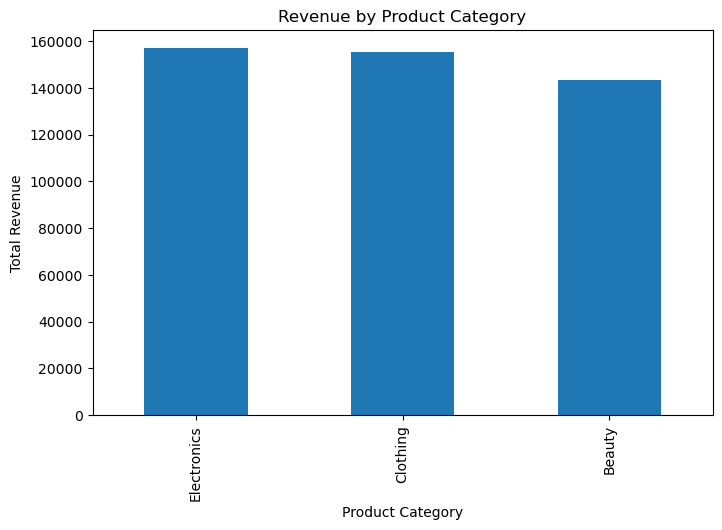

In [13]:
category_sales = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')

plt.show()

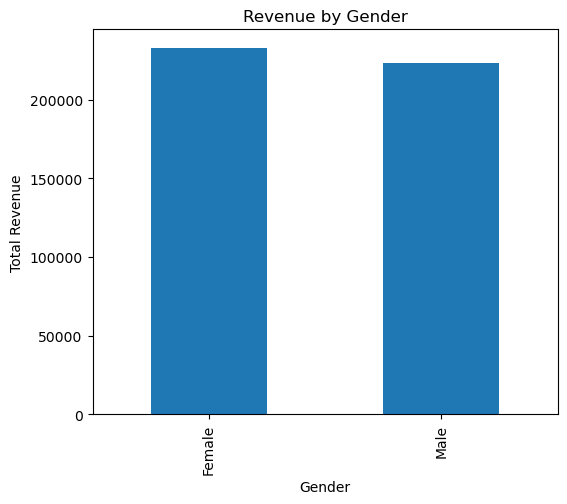

In [14]:
gender_sales = df.groupby('Gender')['Total Amount'].sum()

plt.figure(figsize=(6,5))
gender_sales.plot(kind='bar')

plt.title('Revenue by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Revenue')

plt.show()

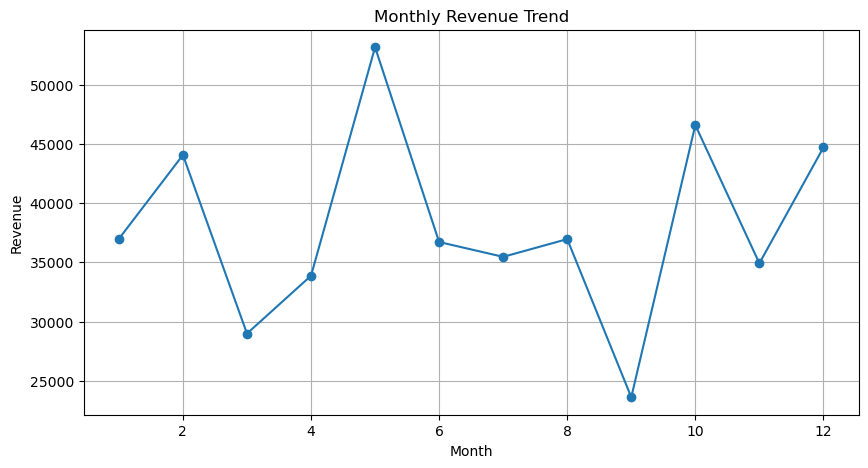

In [15]:
monthly_sales = df.groupby('Month')['Total Amount'].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot(marker='o')

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.grid(True)

plt.show()

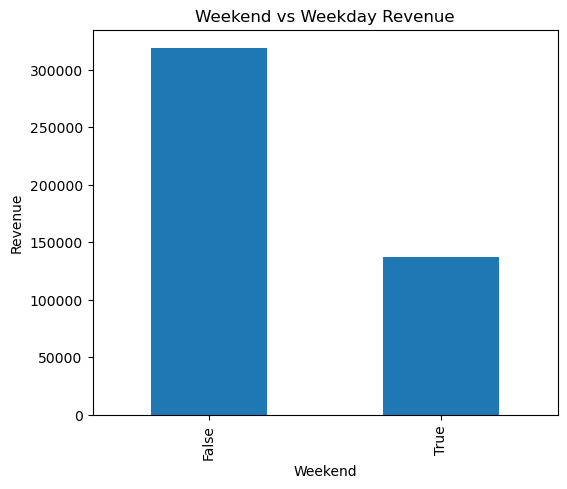

In [16]:
weekend_sales = df.groupby('Weekend')['Total Amount'].sum()

plt.figure(figsize=(6,5))
weekend_sales.plot(kind='bar')

plt.title('Weekend vs Weekday Revenue')
plt.xlabel('Weekend')
plt.ylabel('Revenue')

plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_11224\3613443979.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_sales = df.groupby('Age_Group')['Total Amount'].sum()


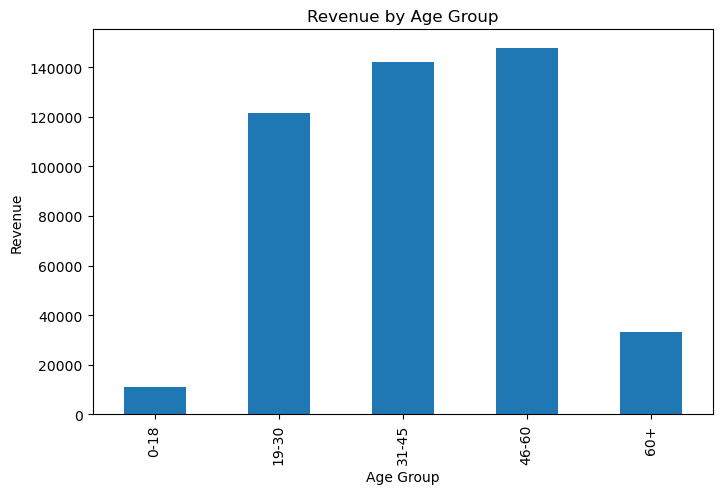

In [17]:
age_sales = df.groupby('Age_Group')['Total Amount'].sum()

plt.figure(figsize=(8,5))
age_sales.plot(kind='bar')

plt.title('Revenue by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Revenue')

plt.show()

In [18]:
# Features
X = df[['Age', 'Quantity', 'Price per Unit', 'Gender', 'Product Category']]

# Target
y = df['Total Amount']

In [19]:
X = pd.get_dummies(X, drop_first=True)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

In [21]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
y_pred = model.predict(X_test)

In [23]:

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 173.20854346790816
RMSE: 204.65578917517294
R2 Score: 0.8569189755192661


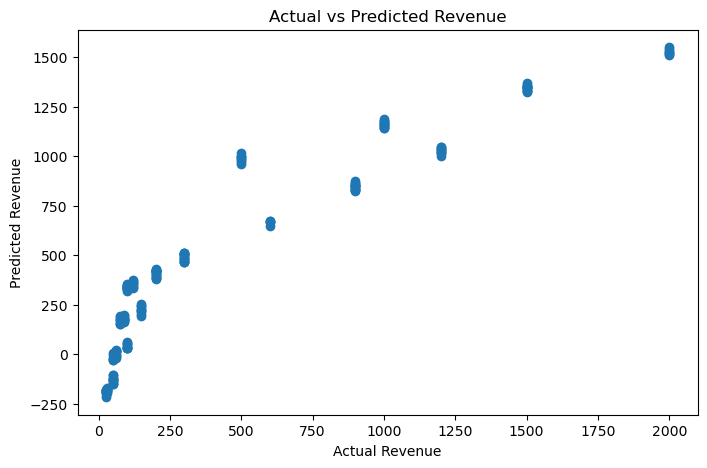

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")

plt.title("Actual vs Predicted Revenue")

plt.show()

In [25]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_})

coefficients.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
1,Quantity,179.617349
3,Gender_Male,11.562099
5,Product Category_Electronics,3.933622
2,Price per Unit,2.485991
0,Age,-0.905103
4,Product Category_Clothing,-5.073932


In [26]:
## Model Performance Insights

#- The Linear Regression model achieved an R² Score of 0.856, indicating that the model explains approximately 85.6% of the variance in revenue.

#- The Mean Absolute Error (MAE) is approximately 173, which means the model predictions are reasonably close to actual revenue values.

#- The RMSE value of 204 indicates acceptable prediction accuracy for a beginner-level business analytics project.

#- Overall, the model performs well and demonstrates the effectiveness of regression analysis for revenue prediction.

In [27]:
## Actual vs Predicted Revenue Insights

#- The scatter plot shows a strong positive relationship between actual and predicted revenue values.

#- Most predicted values closely follow the actual revenue trend, indicating that the model generalizes well on unseen data.

#- Minor deviations are present in lower revenue values, which is common in linear regression models.

#- The visualization confirms that the model captures the overall sales behavior effectively.

In [28]:
## Feature Importance Insights

#- Quantity has the highest positive coefficient, making it the strongest factor influencing total revenue.

#- Price per Unit also positively impacts revenue, indicating that higher-priced products contribute significantly to total sales.

#- Gender and product categories show smaller effects on revenue generation.

#- Age has a slight negative coefficient, suggesting that customer age has limited influence on purchasing value in this dataset.

#- Overall, product quantity and pricing are the primary drivers of retail revenue.